# F7 — Renewal risk and obligations beyond the customer contract

Customer commitments may end before supplier agreements and loan repayments do. The business must then rely on renewals, replacement customers or retained cash to meet the remaining obligations. This lesson measures that exposure.

Read F3 and F4 first. Our business rents computer time and sells it to customers. It does not own hardware that it can sell to cover a gap.

These are **hypothetical** terms. The supplier gets USD 12,000 each month for 24 months. The customer has agreed to pay USD 20,000 each month for only 12 months. After that, we need the customer to renew or someone else to buy the time.

We also owe USD 120,000 on a loan, repaid over 24 months at 12% annual interest divided into monthly charges. The original loan money has already been used in the business. It is not spare cash in this example. We measure extra cash needed during these 24 months, not every dollar needed to start the business.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from itertools import accumulate

from IPython.display import display

from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.financing import (
    build_amortizing_loan_schedule,
    debt_service_coverage,
    level_payment_debt_capacity_usd,
)
from liquid_compute.offtake import (
    build_renewal_receipt_scenarios,
    cash_available_for_debt_service_usd,
    renewal_exposure_summary,
)

loan = build_amortizing_loan_schedule(
    principal_usd=120_000, nominal_annual_interest_rate=0.12, loan_term_months=24
)
receipt_inputs = dict(
    contracted_monthly_usd=20_000, contract_months=12, obligation_months=24
)
monthly_service_usd = loan[1].interest_usd + loan[1].principal_repayment_usd
print(f"Monthly debt service: USD {monthly_service_usd:,.2f}")

Monthly debt service: USD 5,648.82


## Calculate the cash cost of a renewal gap

Suppose we find no customer for months 13, 14 and 15. There are no customer receipts in those months, but rent and loan payments still need paying.

Add one month's rent and loan payment, then multiply by three. That is the cash the gap uses.

We may have saved money during the first 12 months. Subtract those savings before deciding how much new money we need. Using USD 1 from savings is different from needing USD 1 from a new investor.

All earlier cash surpluses remain available to the business. This lesson assumes no owner distributions or restricted reserves; F9 introduces those constraints.

In [3]:
three_month_gap_cost_usd = 3 * (12_000 + monthly_service_usd)
retained_first_year_usd = 12 * (20_000 - 12_000 - monthly_service_usd)
print(f"Three-month gap drawdown: USD {three_month_gap_cost_usd:,.2f}")
print(f"Cash retained through month 12: USD {retained_first_year_usd:,.2f}")
print(
    f"Extra cash needed by end of gap: USD {max(0, three_month_gap_cost_usd - retained_first_year_usd):,.2f}"
)

Three-month gap drawdown: USD 52,946.45
Cash retained through month 12: USD 28,214.20
Extra cash needed by end of gap: USD 24,732.25


The loan payment is **USD 5,648.82 a month**. Even after 12 payments, we still owe **USD 63,577.87** when the customer contract ends.

During the gap, cash must cover rent and loan payments together. Earlier savings cover part of the bill, so the extra money needed is smaller than the whole gap cost.

## Separate contracted receipts from renewal assumptions

Compare three paths: no new customer, immediate renewal at USD 20,000 a month, and renewal after three months without customer receipts at USD 17,000 a month.

The renewal prices are hypothetical possibilities, not forecasts from rental quotes. Every path runs through month 24 so we keep all supplier and loan bills. We reuse F3's cash rules and F1's loan calculation.

In [4]:
contract_only = build_renewal_receipt_scenarios(
    **receipt_inputs, renewal_gap_months=0, renewal_monthly_usd=0
)
immediate = build_renewal_receipt_scenarios(
    **receipt_inputs, renewal_gap_months=0, renewal_monthly_usd=20_000
)
stressed = build_renewal_receipt_scenarios(
    **receipt_inputs, renewal_gap_months=3, renewal_monthly_usd=17_000
)


def net_cash(rows, debt=loan):
    cfads = cash_available_for_debt_service_usd(
        [r.total_receipts_usd for r in rows], [0] + [12_000] * 24
    )
    return tuple(
        c
        - (
            debt[t].interest_usd + debt[t].principal_repayment_usd
            if 0 < t < len(debt)
            else 0
        )
        for t, c in enumerate(cfads)
    )


show_finance_table(
    ["Month", "Contracted (USD)", "Assumed renewal (USD)", "Total receipt (USD)"],
    [
        [
            r.month_offset,
            r.contracted_receipts_usd,
            r.assumed_renewal_receipts_usd,
            r.total_receipts_usd,
        ]
        for r in stressed
        if r.month_offset in (12, 13, 15, 16, 24)
    ],
)

| Month | Contracted (USD) | Assumed renewal (USD) | Total receipt (USD) |
| --- | --- | --- | --- |
| 12.00 | 20,000.00 | 0.00 | 20,000.00 |
| 13.00 | 0.00 | 0.00 | 0.00 |
| 15.00 | 0.00 | 0.00 | 0.00 |
| 16.00 | 0.00 | 17,000.00 | 17,000.00 |
| 24.00 | 0.00 | 17,000.00 | 17,000.00 |

In the delayed path, no customer money arrives in months 13–15. Nine renewed payments arrive in months 16–24.

The original contract contributes **USD 240,000** in every path. Extra money from renewal is shown separately because it is not yet promised.

## Compare retained cash with remaining obligations

The chart marks month 12, when the customer contract ends. Cash retained from earlier months remains available to meet later payments; the balance is not reset at contract expiry.

The summary also shows how much cash is used after month 12. That is different from how much extra money the whole business needs.

You can change the gap or renewal price in the input cells. Optional controls use their own inputs and do not change the saved examples.

| Case | Debt at expiry (USD) | Post-expiry drawdown (USD) | Whole-path initial buffer (USD) |
| --- | --- | --- | --- |
| Contract only | 63,577.87 | 211,785.80 | 183,571.60 |
| Immediate renewal | 63,577.87 | 0.00 | 0.00 |
| Gap and lower price | 63,577.87 | 58,785.80 | 30,571.60 |

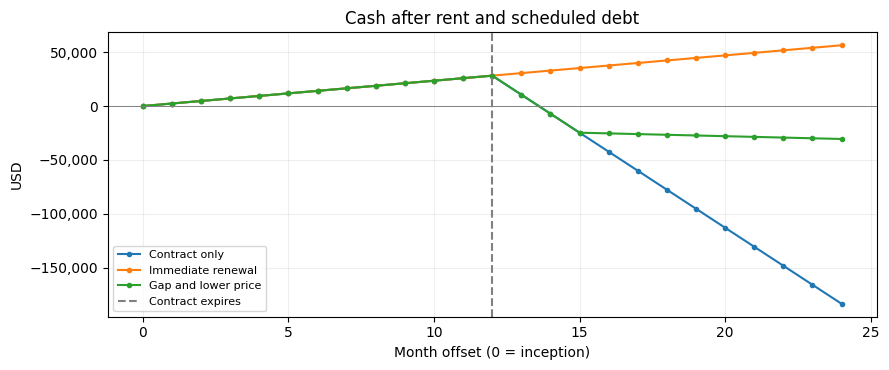

In [5]:
def summary(scenarios, debt=loan):
    output = []
    for name, rows in scenarios.items():
        result = renewal_exposure_summary(
            net_cash_after_debt_usd=net_cash(rows, debt),
            loan_schedule=debt,
            contract_months=12,
        )
        output.append(
            [
                name,
                result.debt_at_expiry_usd,
                result.post_expiry_drawdown_usd,
                result.required_initial_cash_buffer_usd,
            ]
        )
    show_finance_table(
        [
            "Case",
            "Debt at expiry (USD)",
            "Post-expiry drawdown (USD)",
            "Whole-path initial buffer (USD)",
        ],
        output,
    )


cases = {
    "Contract only": contract_only,
    "Immediate renewal": immediate,
    "Gap and lower price": stressed,
}
summary(cases)
display(
    plot_finance_series(
        {name: tuple(accumulate(net_cash(rows))) for name, rows in cases.items()},
        title="Cash after rent and scheduled debt",
        marker_month=12,
    )
)


def renewal_explorer(values, source=receipt_inputs.copy(), debt=loan):
    from itertools import accumulate

    from liquid_compute.offtake import (
        build_renewal_receipt_scenarios,
        cash_available_for_debt_service_usd,
    )

    rows = build_renewal_receipt_scenarios(
        **source,
        renewal_gap_months=values["Renewal gap (months)"],
        renewal_monthly_usd=values["Renewal cash (USD/month)"],
    )
    cfads = cash_available_for_debt_service_usd(
        [r.total_receipts_usd for r in rows], [0] + [12_000] * 24
    )
    cash = [
        c - (debt[t].interest_usd + debt[t].principal_repayment_usd if t else 0)
        for t, c in enumerate(cfads)
    ]
    return {"Cash after debt": tuple(accumulate(cash))}


explore_finance_series(
    {"Renewal gap (months)": 3, "Renewal cash (USD/month)": 17_000.0},
    renewal_explorer,
    title="Assumed renewal and cash after debt",
    marker_month=12,
);

Immediate renewal maintains the monthly cash surplus. Without renewal, supplier and loan payments continue with no offsetting customer receipts.

Renewal at USD 17,000 still leaves a problem: after USD 12,000 rent, only USD 5,000 remains. That is less than the USD 5,648.82 loan payment.

## Experiment 1 — Delay renewal without changing the price

Keep renewed receipts at USD 20,000 but wait three months for them to start. We lose three USD 20,000 payments. Supplier and loan bills stay the same. Once the customer starts paying, the original monthly surplus returns.

In [6]:
gap_only = build_renewal_receipt_scenarios(
    **receipt_inputs, renewal_gap_months=3, renewal_monthly_usd=20_000
)
summary({"No gap": immediate, "Three-month gap": gap_only})

| Case | Debt at expiry (USD) | Post-expiry drawdown (USD) | Whole-path initial buffer (USD) |
| --- | --- | --- | --- |
| No gap | 63,577.87 | 0.00 | 0.00 |
| Three-month gap | 63,577.87 | 52,946.45 | 24,732.25 |

The cash balance falls during the renewal gap and recovers once sales resume. Its lowest point determines the additional funding needed during the period.

A positive final balance can conceal an earlier funding shortfall. The plan needs enough cash at each payment date, including during the renewal gap.

## Experiment 2 — Lower the renewal price after the gap

Keep the three-month gap. Reduce renewed monthly receipts from USD 20,000 to USD 17,000.

Now each of the nine renewed months brings USD 3,000 less. This is a smaller payment, not another delay.

In [7]:
summary({"Gap, USD 20,000 renewal": gap_only, "Gap, USD 17,000 renewal": stressed})
show_finance_table(
    ["Renewal assumption", "CFADS (USD/month)", "Debt coverage"],
    [
        [
            "USD 20,000",
            8_000,
            debt_service_coverage(
                cfads_usd=8_000, debt_service_usd=monthly_service_usd
            ),
        ],
        [
            "USD 17,000",
            5_000,
            debt_service_coverage(
                cfads_usd=5_000, debt_service_usd=monthly_service_usd
            ),
        ],
    ],
)

| Case | Debt at expiry (USD) | Post-expiry drawdown (USD) | Whole-path initial buffer (USD) |
| --- | --- | --- | --- |
| Gap, USD 20,000 renewal | 63,577.87 | 52,946.45 | 24,732.25 |
| Gap, USD 17,000 renewal | 63,577.87 | 58,785.80 | 30,571.60 |

| Renewal assumption | CFADS (USD/month) | Debt coverage |
| --- | --- | --- |
| USD 20,000 | 8,000.00 | 1.42 |
| USD 17,000 | 5,000.00 | 0.89 |

Nine payments that are USD 3,000 smaller mean **USD 27,000 less cash**. After rent, there is not enough each month to make the full loan payment. The lowest cash balance now comes later.

Counting only the three months without customer receipts would miss this continuing shortage.

## Experiment 3 — Finish the loan when the customer contract ends

Repay the same USD 120,000 in 12 months instead of 24. Debt will end with the customer contract, but each payment must be bigger.

The supplier still needs paying for 24 months. Ending the loan does not end the rental agreement.

In [8]:
short_loan = build_amortizing_loan_schedule(
    principal_usd=120_000, nominal_annual_interest_rate=0.12, loan_term_months=12
)
short_service = short_loan[1].interest_usd + short_loan[1].principal_repayment_usd
supported_by_contract = level_payment_debt_capacity_usd(
    cfads_usd=(8_000,) * 12, minimum_dscr=1.25, nominal_annual_interest_rate=0.12
)
show_finance_table(
    [
        "Debt term",
        "Monthly service (USD)",
        "Contract-period DSCR",
        "Debt after month 12 (USD)",
    ],
    [
        [
            "24 months",
            monthly_service_usd,
            debt_service_coverage(
                cfads_usd=8_000, debt_service_usd=monthly_service_usd
            ),
            loan[12].closing_debt_usd,
        ],
        [
            "12 months",
            short_service,
            debt_service_coverage(cfads_usd=8_000, debt_service_usd=short_service),
            short_loan[-1].closing_debt_usd,
        ],
    ],
)
print(f"Twelve-month capacity at 1.25x: USD {supported_by_contract:,.2f}")

| Debt term | Monthly service (USD) | Contract-period DSCR | Debt after month 12 (USD) |
| --- | --- | --- | --- |
| 24 months | 5,648.82 | 1.42 | 63,577.87 |
| 12 months | 10,661.85 | 0.75 | 0.00 |

Twelve-month capacity at 1.25x: USD 72,032.50


The shorter loan asks for too much each month. The USD 8,000 left after rent cannot meet the chosen coverage rule, and the higher payments cause an earlier cash shortage.

Matching the loan's end date to the customer's end date is not enough. F4 also checks whether the amount borrowed is affordable.

The final comparison keeps earlier savings and every remaining rental bill. Label renewal money as an assumption before relying on it. The reseller has no hardware sale proceeds available to cover a shortfall.

In [9]:
summary(
    {
        "Contract only, 24-month debt": contract_only,
        "Renewal stress, 24-month debt": stressed,
    }
)
summary({"Contract only, 12-month debt": contract_only}, debt=short_loan)

| Case | Debt at expiry (USD) | Post-expiry drawdown (USD) | Whole-path initial buffer (USD) |
| --- | --- | --- | --- |
| Contract only, 24-month debt | 63,577.87 | 211,785.80 | 183,571.60 |
| Renewal stress, 24-month debt | 63,577.87 | 58,785.80 | 30,571.60 |

| Case | Debt at expiry (USD) | Post-expiry drawdown (USD) | Whole-path initial buffer (USD) |
| --- | --- | --- | --- |
| Contract only, 12-month debt | 0.00 | 144,000.00 | 175,942.26 |

## Next — What changes when we own or lease equipment?

Continue to **F8: GPU ownership, leasing, and residual value**. It changes the business model before counting hardware sales.

The [World Bank's transaction discussion](https://ppp.worldbank.org/financing/issues-in-project-financed-transactions) explains why customer demand and repayment cash matter. Our renewal prices and waiting periods are hypothetical possibilities. We have not measured how likely they are.